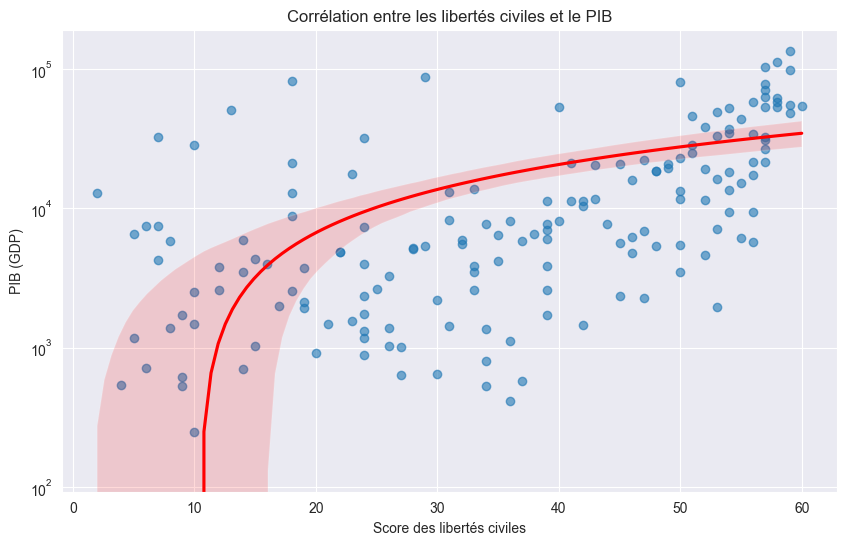

Coefficient de corrélation : 0.489


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Définir le chemin des fichiers CSV
chemin_libertes = "CSVs/civil_liberties_score_fh_new.csv"
chemin_gdp = "CSVs/gdp_long.csv"

# Charger les données
df_libertes = pd.read_csv(chemin_libertes)
df_gdp = pd.read_csv(chemin_gdp)

# Garder les colonnes utiles
df_libertes = df_libertes[['Country', 'Year', 'Civil liberties score']].dropna()
df_gdp = df_gdp[['Country', 'Year', 'GDP']].dropna()

# Filtrer pour la dernière année commune entre les deux datasets
annee_commune = min(df_libertes['Year'].max(), df_gdp['Year'].max())
df_libertes = df_libertes[df_libertes['Year'] == annee_commune]
df_gdp = df_gdp[df_gdp['Year'] == annee_commune]

# Fusionner les datasets sur le pays et l'année
df = pd.merge(df_libertes, df_gdp, on=["Country", "Year"], how="inner")

# Visualisation : Corrélation Libertés Civiles vs PIB
plt.figure(figsize=(10, 6))
sns.regplot(x=df['Civil liberties score'], y=df['GDP'], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xlabel("Score des libertés civiles")
plt.ylabel("PIB (GDP)")
plt.title("Corrélation entre les libertés civiles et le PIB")
plt.yscale('log')  # Mise à l'échelle logarithmique pour mieux voir les variations

plt.show()

# Afficher le coefficient de corrélation
correlation = df[['Civil liberties score', 'GDP']].corr().iloc[0,1]
print(f"Coefficient de corrélation : {correlation:.3f}")


il y a une corrélation positive modérée entre les libertés civiles et le PIB.

Que signifie ce résultat ?
0.489 est une corrélation modérée → Il y a une tendance générale où les pays avec plus de libertés civiles ont un PIB plus élevé.

Cependant, ce n'est pas une corrélation forte (≥ 0.7), ce qui indique que d'autres facteurs influencent également le PIB.

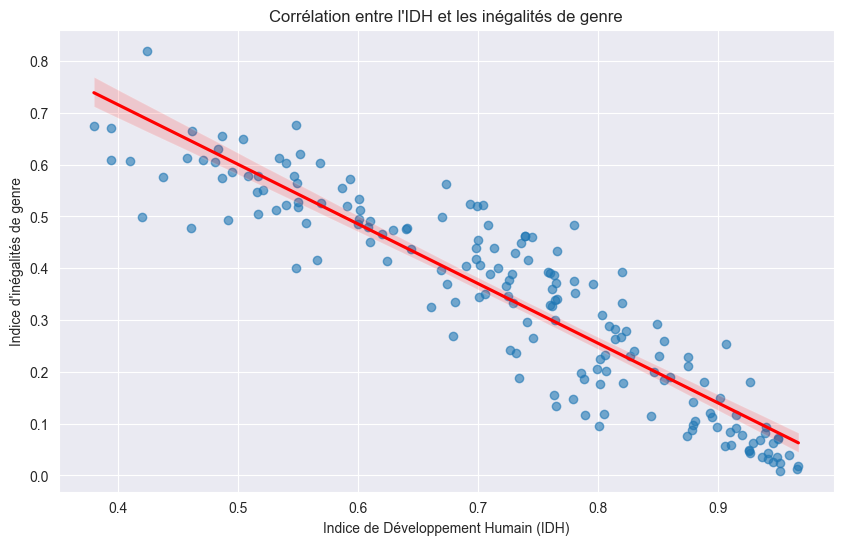

Coefficient de corrélation : -0.918


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Définir le chemin du fichier CSV
chemin_hdi = "CSVs/hdr_general.csv"

# Charger les données
df_hdi = pd.read_csv(chemin_hdi)

# Garder les colonnes utiles
df_hdi = df_hdi[['Country', 'year', 'hdi', 'gender_inequality']].dropna()

# Filtrer pour la dernière année disponible
annee_max = df_hdi['year'].max()
df_hdi = df_hdi[df_hdi['year'] == annee_max]

# Visualisation : Corrélation IDH vs Inégalités de genre
plt.figure(figsize=(10, 6))
sns.regplot(x=df_hdi['hdi'], y=df_hdi['gender_inequality'], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xlabel("Indice de Développement Humain (IDH)")
plt.ylabel("Indice d'inégalités de genre")
plt.title("Corrélation entre l'IDH et les inégalités de genre")

plt.show()

# Afficher le coefficient de corrélation
correlation = df_hdi[['hdi', 'gender_inequality']].corr().iloc[0,1]
print(f"Coefficient de corrélation : {correlation:.3f}")


Que signifie ce résultat ?
📉 Plus un pays a un IDH élevé, plus il a tendance à réduire les inégalités de genre.

Une corrélation de -0.918 est extrêmement forte → Cela indique que les pays les plus développés ont généralement moins d’inégalités de genre.

Cette tendance est cohérente avec ce qu’on observe dans le monde → Les pays avec un IDH élevé (comme les pays nordiques) ont généralement une meilleure égalité entre hommes et femmes, notamment en termes d'éducation, d'emploi et de droits sociaux.

Index(['Country', 'year', 'Life Ladder', 'Log GDP per capita',
       'Social support', 'Healthy life expectancy at birth',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'Positive affect', 'Negative affect'],
      dtype='object')


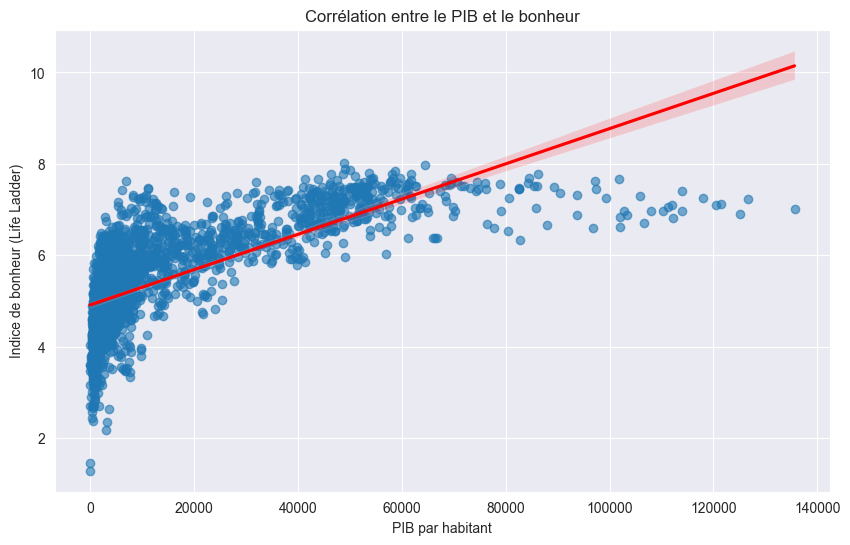

Coefficient de corrélation : 0.706


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Définir le chemin des fichiers CSV
chemin_gdp = "CSVs/gdp_long.csv"
chemin_bonheur = "CSVs/world_happiness_report_2024.csv"

# Charger les données
df_gdp = pd.read_csv(chemin_gdp)
df_bonheur = pd.read_csv(chemin_bonheur)

# Vérifier les noms de colonnes du fichier bonheur
print(df_bonheur.columns)

# Garder les colonnes utiles et renommer pour fusionner plus facilement
df_gdp = df_gdp[['Country', 'Year', 'GDP']].rename(columns={'GDP': 'PIB'})
df_bonheur = df_bonheur[['Country', 'year', 'Life Ladder']].rename(columns={'Life Ladder': 'indice_bonheur', 'year': 'Year'})

# Fusionner les deux datasets sur le pays et l'année
df = pd.merge(df_gdp, df_bonheur, on=['Country', 'Year']).dropna()

# Visualisation : Corrélation entre PIB et bonheur
plt.figure(figsize=(10, 6))
sns.regplot(x=df['PIB'], y=df['indice_bonheur'], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xlabel("PIB par habitant")
plt.ylabel("Indice de bonheur (Life Ladder)")
plt.title("Corrélation entre le PIB et le bonheur")

plt.show()

# Calcul de la corrélation
correlation = df[['PIB', 'indice_bonheur']].corr().iloc[0,1]
print(f"Coefficient de corrélation : {correlation:.3f}")


Interprétation du résultat :
Un coefficient de corrélation de 0.706 suggère que les pays ayant un PIB plus élevé ont tendance à avoir des niveaux de bonheur plus élevés.

Cela montre qu'il existe une relation positive, mais cette relation n'est pas parfaite. Le PIB est un facteur influent pour le bonheur, mais il n'est pas le seul. D'autres facteurs comme la qualité de vie, les services sociaux, l'éducation, la santé, et l'égalité sociale peuvent également jouer un rôle important dans le bien-être des habitants.

La corrélation n'est pas maximale (qui serait de 1), ce qui signifie qu'il existe des exceptions où des pays avec un PIB relativement élevé peuvent avoir un indice de bonheur moins élevé en raison de problèmes comme des inégalités ou des conflits sociaux.

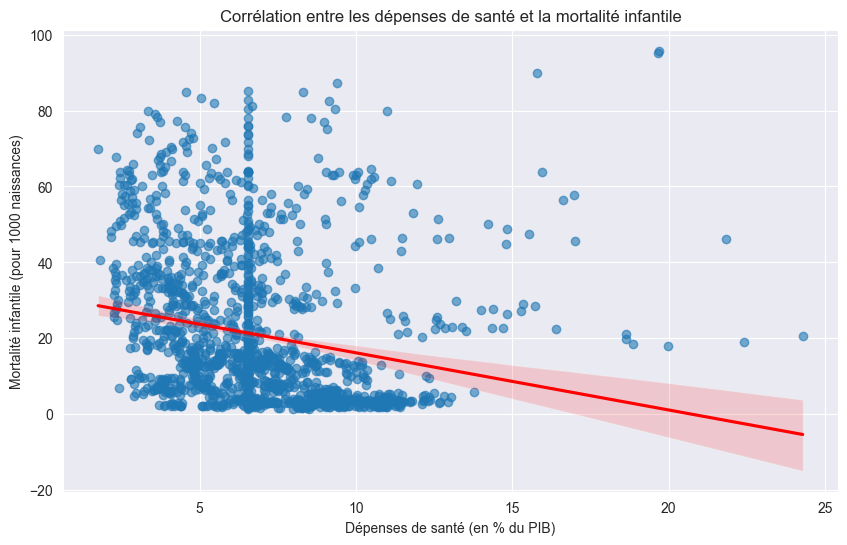

Coefficient de corrélation : -0.207


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Définir le chemin du fichier CSV des données de santé
chemin_sante = "CSVs/world_population_and_health.csv"

# Charger les données
df_sante = pd.read_csv(chemin_sante)

# Garder les colonnes nécessaires et renommer pour fusionner facilement
df_sante = df_sante[['Country', 'Year', 'health_exp', 'infant_mortality']].rename(columns={
    'health_exp': 'dépenses_santé', 
    'infant_mortality': 'mortalité_infantile'
})

# Supprimer les lignes avec des valeurs manquantes
df_sante = df_sante.dropna()

# Visualisation : Corrélation entre les dépenses de santé et la mortalité infantile
plt.figure(figsize=(10, 6))
sns.regplot(x=df_sante['dépenses_santé'], y=df_sante['mortalité_infantile'], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xlabel("Dépenses de santé (en % du PIB)")
plt.ylabel("Mortalité infantile (pour 1000 naissances)")
plt.title("Corrélation entre les dépenses de santé et la mortalité infantile")

plt.show()

# Calcul de la corrélation
correlation = df_sante[['dépenses_santé', 'mortalité_infantile']].corr().iloc[0,1]
print(f"Coefficient de corrélation : {correlation:.3f}")


Le coefficient de corrélation de -0.207 indique une légère corrélation négative entre les dépenses de santé d'un pays et la mortalité infantile. Voici l'interprétation détaillée :

Interprétation du résultat :
Un coefficient de -0.207 suggère une faible corrélation négative entre les dépenses de santé et la mortalité infantile.

En d'autres termes, les pays avec des dépenses de santé plus élevées ne semblent pas nécessairement avoir une mortalité infantile plus faible. La relation entre ces deux variables est faible, ce qui signifie qu'il y a probablement d'autres facteurs influençant la mortalité infantile au-delà des simples dépenses de santé.

Quelques explications possibles :
Qualité des soins de santé : Les dépenses de santé ne se traduisent pas toujours par une amélioration directe de la qualité des soins, ce qui pourrait affecter la mortalité infantile. Par exemple, même avec des dépenses élevées, un pays peut avoir une mauvaise gestion de ses systèmes de santé.

Infrastructures et accès aux soins : Dans certains pays, des dépenses de santé plus élevées peuvent ne pas être accompagnées d'un accès universel aux soins ou d'un système de santé bien développé.

Facteurs sociaux et économiques : La mortalité infantile est également influencée par des facteurs comme l'éducation, le statut socio-économique, et les conditions de vie des populations, qui ne sont pas capturés uniquement par les dépenses de santé.

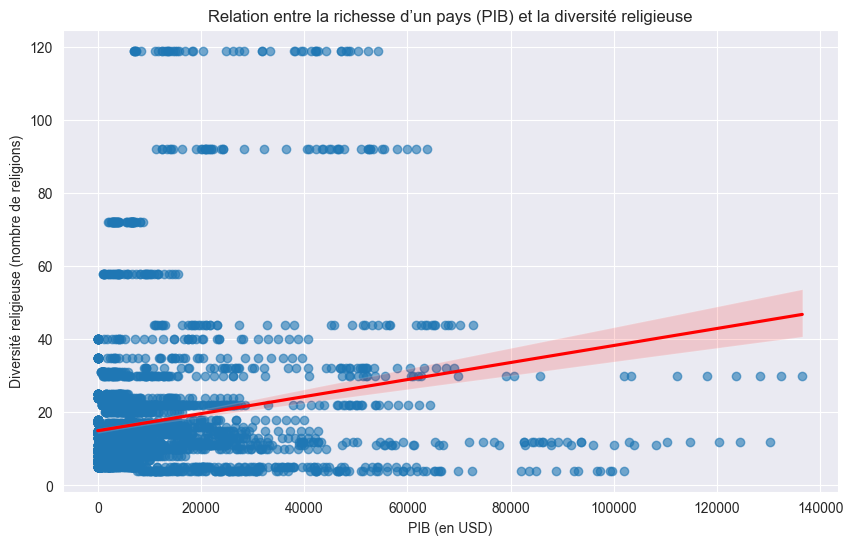

Coefficient de corrélation : 0.211


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Définir le chemin des fichiers CSV
chemin_religion = "CSVs/world_religious.csv"
chemin_gdp = "CSVs/gdp_long.csv"

# Charger les données
df_religion = pd.read_csv(chemin_religion)
df_gdp = pd.read_csv(chemin_gdp)

# Calculer la diversité religieuse (nombre de religions par pays)
diversite_religieuse = df_religion.groupby('Country')['Religion'].nunique().reset_index()
diversite_religieuse.rename(columns={'Religion': 'diversite_religieuse'}, inplace=True)

# Garder les colonnes utiles du PIB
df_gdp = df_gdp[['Country', 'Year', 'GDP']].rename(columns={'GDP': 'PIB'})

# Fusionner les données sur 'Country'
df = pd.merge(diversite_religieuse, df_gdp, on='Country')

# Supprimer les valeurs manquantes
df = df.dropna()

# Visualisation de la relation entre le PIB et la diversité religieuse
plt.figure(figsize=(10, 6))
sns.regplot(x=df['PIB'], y=df['diversite_religieuse'], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xlabel("PIB (en USD)")
plt.ylabel("Diversité religieuse (nombre de religions)")
plt.title("Relation entre la richesse d’un pays (PIB) et la diversité religieuse")
plt.show()

# Calcul de la corrélation
correlation = df[['PIB', 'diversite_religieuse']].corr().iloc[0, 1]
print(f"Coefficient de corrélation : {correlation:.3f}")


Interprétation du résultat :
Un coefficient de 0.211 montre une légère tendance à la corrélation positive. Cela signifie que, globalement, dans les pays avec un PIB plus élevé, il y a légèrement plus de diversité religieuse. Cependant, cette relation est faible.

Quelques points à considérer :
Bien que les pays riches tendent à avoir une diversité religieuse légèrement plus élevée, cela ne signifie pas nécessairement qu'une forte richesse entraîne une plus grande diversité religieuse. La corrélation est faible, donc la richesse ne semble pas être un facteur déterminant majeur de la diversité religieuse.

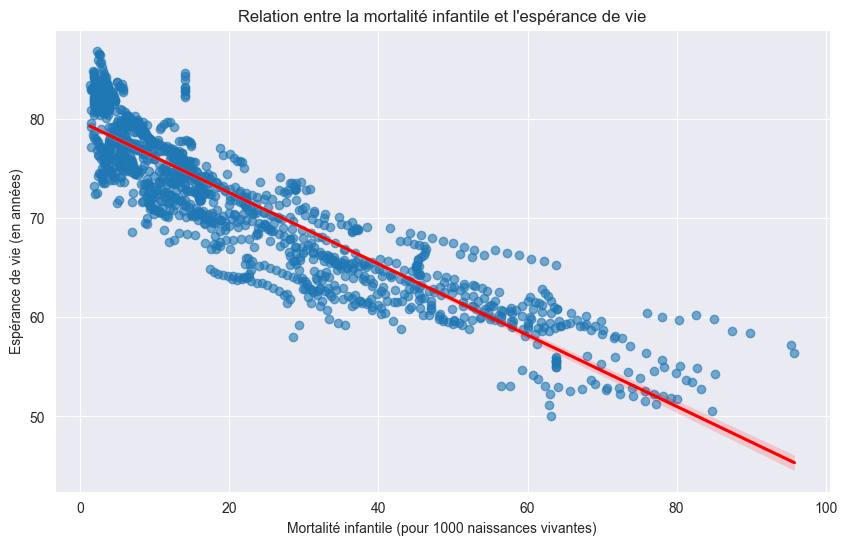

Coefficient de corrélation : -0.905


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Définir le chemin des fichiers CSV
chemin_sante = "CSVs/world_population_and_health.csv"
chemin_hdr = "CSVs/hdr_general.csv"

# Charger les données
df_sante = pd.read_csv(chemin_sante)
df_hdr = pd.read_csv(chemin_hdr)

# Garder les colonnes nécessaires
df_sante = df_sante[['Country', 'Year', 'infant_mortality']].rename(columns={'infant_mortality': 'mortalite_infantile'})
df_hdr = df_hdr[['Country', 'year', 'life_expectancy']].rename(columns={'life_expectancy': 'esperance_vie'})

# Fusionner les données sur 'Country' et 'Year'
df = pd.merge(df_sante, df_hdr, left_on=['Country', 'Year'], right_on=['Country', 'year'])

# Supprimer les lignes avec des valeurs manquantes
df = df.dropna()

# Visualisation de la relation entre la mortalité infantile et l'espérance de vie
plt.figure(figsize=(10, 6))
sns.regplot(x='mortalite_infantile', y='esperance_vie', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xlabel("Mortalité infantile (pour 1000 naissances vivantes)")
plt.ylabel("Espérance de vie (en années)")
plt.title("Relation entre la mortalité infantile et l'espérance de vie")
plt.show()

# Calcul de la corrélation
correlation = df[['mortalite_infantile', 'esperance_vie']].corr().iloc[0, 1]
print(f"Coefficient de corrélation : {correlation:.3f}")


Le coefficient de corrélation de -0.905 indique une forte corrélation négative entre la mortalité infantile et l'espérance de vie d'un pays.

Interprétation du résultat :
Une corrélation négative de -0.905 montre une relation forte entre les deux variables : plus la mortalité infantile est faible, plus l'espérance de vie est élevée dans un pays.

Cela suggère que, dans les pays avec une meilleure prise en charge de la santé infantile (et donc une mortalité infantile réduite), l'espérance de vie de la population tend également à être plus longue. Ce phénomène peut être dû à des systèmes de santé plus efficaces, des politiques de santé publique améliorées, et une qualité de vie générale plus élevée.